In [32]:
import os
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [33]:
from utils.plot_style import set_plot_style 
set_plot_style()

# Reflectivity measurements of mirrors

In [109]:
def linear(x, T, offset):
    return T*x + offset

## Single file load

### Load data

In [121]:
# path_folder_data = r'./data/data_pm100a/reflectivity_laseroptik_T004Q2 05 19'
# path_folder_data = r'./data/data_pm100a/reflectivity/2026-05-20_metallic_unknown_001'
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-05-20_laseroptik-T004Q2_002'
# path_folder_data = r'./data/data_pm100a/reflectivity/2026-05-26_laseroptic_panda_hr_001'
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-05-29_laseroptic_panda_coupler_5_002'  # COUPLER PUMP
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-05-29_laseroptic_panda_coupler_5_005'  # COUPLER PZT (inner face)
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-06-01_eq15b_curved_roc100_HR426_002'
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-06-01_eq15b_flat_HR426_half_inch_001'
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-06-01_eq15b_HR_HR_1inch_001'
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-06-01_eq15b_flat_HR426_1inch_001'
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-06-01_eq15b_flat_HR426_1inch_face2_001'
path_folder_data = r'./data/data_pm100a/reflectivity/2026-05-26_laseroptic_panda_roc_150_001'

folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['reflectivity_laseroptic_panda_roc_150', 'temp.json']


In [122]:
# name_exp = "pm100a"
# name_exp = "reflectivity_metallic_unknown"
# name_exp = "reflectivity_laseroptic_panda_hr"
# name_exp = "transmitivity_laseroptik-T004Q2"
# name_exp = "transmitivity_eq15b_curved_roc100_HR426"
# name_exp = "transmitivity_eq15b_flat_HR426_half_inch"
# name_exp = "transmitivity_eq15b_HR_HR_1inch"
# name_exp = "transmitivity_eq15b_flat_HR426_1inch"
# name_exp = "transmitivity_eq15b_flat_HR426_1inch_face2"
name_exp = "reflectivity_laseroptic_panda_roc_150"

folder_data_files = os.listdir(path_folder_data + "/" + name_exp)
print(folder_data_files)

['2026_05_26__11_43_37__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_43_49__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_44_13__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_44_27__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_44_41__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_44_58__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_45_23__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_45_39__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_46_02__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_46_16__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_46_33__reflectivity_laseroptic_panda_roc_150.h5', '2026_05_26__11_46_59__reflectivity_laseroptic_panda_roc_150.h5']


The file are individual records. But the measurements was:
- first in front of mirror
- second behind mirror

So first file of folder is front, second is back, then we switch the power input, 3rd is front, 4th is back, and so on. We plot the transmitted power VS the input power from the h5 files.

In [123]:
aqm = AcquisitionAnalysisManager(os.path.join(path_folder_data, name_exp))

P_in = []
P_in_error = []
P_tr = []
P_tr_error = []

for f_front, f_back in zip(folder_data_files[0::2], folder_data_files[1::2]):

    aqm.analysis_cell(filename=os.path.join(path_folder_data, name_exp, f_front))
    P_front = aqm.data["mean_mW"]
    P_front_error = aqm.data["error_mW"]

    aqm.analysis_cell(filename=os.path.join(path_folder_data, name_exp, f_back))
    P_back = aqm.data["mean_mW"]
    P_back_error = aqm.data["error_mW"]

    P_in.append(P_front)
    P_in_error.append(P_front_error)
    P_tr.append(P_back)
    P_tr_error.append(P_back_error)

INFO:2026_05_26__11_43_37__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_43_49__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_44_13__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_44_27__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_44_41__reflectivity_laseroptic_panda_roc_150


...

INFO:2026_05_26__11_45_39__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_46_02__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_46_16__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_46_33__reflectivity_laseroptic_panda_roc_150


INFO:2026_05_26__11_46_59__reflectivity_laseroptic_panda_roc_150


In [124]:
# Incident power
P_in = np.array(P_in)
P_in_error = np.array(P_in_error)

# Transmitted power (or reflected power depending on what measurement is done)
P_tr = np.array(P_tr)
P_tr_error = np.array(P_tr_error)

In [125]:
# Check arrays
print("Power in (mW): ", P_in, "Error: ", P_in_error)
print("Power transmitted/reflected (mW): ", P_tr, "Error: ", P_tr_error)

Power in (mW):  [10.21455502 21.44447687 30.81165859 39.91861249 50.23413524 60.57434662] Error:  [0.0225478  0.02979106 0.13437767 0.02182648 0.04142513 0.0223165 ]
Power transmitted/reflected (mW):  [ 9.86998547 20.8509909  29.51874594 39.29015417 48.60591125 60.68337093] Error:  [0.0486445  0.05852048 0.03071164 0.03847029 0.03672048 0.02837524]


In [126]:
# Fit for transmitted power
popt, pcov = curve_fit(linear, P_in, P_tr)
T, offset = popt
T_err, offset_err = np.sqrt(np.diag(pcov))

R = 1 - T
R_err = T_err

xfit = np.linspace(0, 1.05*np.max(P_in), 300)

In [127]:
# Fit for reflected power

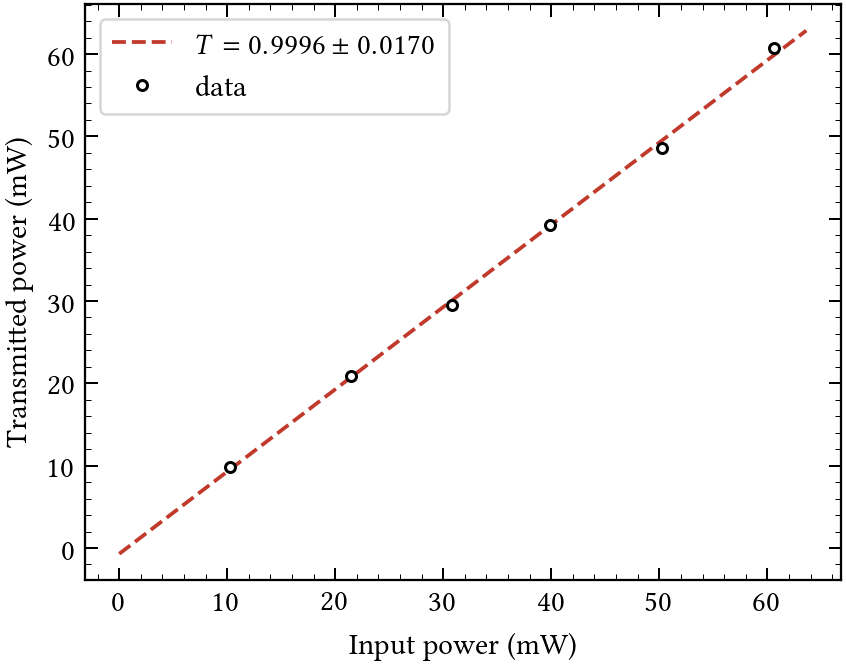

Transmission coefficient T = 0.999551 ± 0.017049
Reflectivity coefficient R = 1 - T = 0.000449 ± 0.017049
Fit offset = -0.714 ± 0.671 mW


In [128]:
# Plotting
plt.figure(figsize=(5, 4))

plt.plot(xfit, linear(xfit, *popt),
    "--",
    color="#C0392B",
    # color="#2E86AB",
    linewidth=1.5,
    # label=rf"$R={T:.4f}\pm{T_err:.4f}$") # Switch commented line depending on what is plotted
    label=rf"$T={T:.4f}\pm{T_err:.4f}$")

plt.plot(P_in, P_tr,
    "o",
    color="black",
    markersize=4,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="data")

plt.xlabel("Input power (mW)")
plt.ylabel("Transmitted power (mW)") # Switch commented line depending on what is plotted
# plt.ylabel("Reflected Power (mW)")
plt.legend()
plt.tight_layout()
plt.savefig(f"./plot/figure/{name_exp}_002.svg", dpi=300)
plt.show()

print(f"Transmission coefficient T = {T:.6f} ± {T_err:.6f}")
print(f"Reflectivity coefficient R = 1 - T = {R:.6f} ± {R_err:.6f}")
print(f"Fit offset = {offset:.3f} ± {offset_err:.3f} mW")

## Comparison 780/390 Reflectivities

Load data

In [4]:
SAMPLE = "CCM254-100-P01"
DATE = "2026-05-21"
index_780 = "001"
index_390 = "003"

In [5]:
# 780 nm
folder_780 = rf"./data/data_pm100a/reflectivity/{DATE}_{SAMPLE}_{index_780}"
name_exp_780 = f"reflectivity_{SAMPLE}"

aqm = AcquisitionAnalysisManager(os.path.join(folder_780, name_exp_780))
files_780 = sorted(os.listdir(os.path.join(folder_780, name_exp_780)))

P_in_780, P_out_780 = [], []
for f_front, f_back in zip(files_780[0::2], files_780[1::2]):
    aqm.analysis_cell(filename=os.path.join(folder_780, name_exp_780, f_front))
    P_in_780.append(float(aqm.data["mean_mW"]))
    aqm.analysis_cell(filename=os.path.join(folder_780, name_exp_780, f_back))
    P_out_780.append(float(aqm.data["mean_mW"]))

P_in_780, P_out_780 = np.array(P_in_780), np.array(P_out_780)

INFO:2026_05_21__09_25_31__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_25_54__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_26_15__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_26_29__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_26_57__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_27_13__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_27_35__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_28_16__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_28_37__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_28_51__reflectivity_CCM254-100-P01


In [6]:
# 390 nm
folder_390 = rf"./data/data_pm100a/reflectivity/{DATE}_{SAMPLE}_{index_390}"
name_exp_390 = f"reflectivity_{SAMPLE}"

aqm = AcquisitionAnalysisManager(os.path.join(folder_390, name_exp_390))
files_390 = sorted(os.listdir(os.path.join(folder_390, name_exp_390)))

P_in_390, P_out_390 = [], []
for f_front, f_back in zip(files_390[0::2], files_390[1::2]):
    aqm.analysis_cell(filename=os.path.join(folder_390, name_exp_390, f_front))
    P_in_390.append(float(aqm.data["mean_mW"]))
    aqm.analysis_cell(filename=os.path.join(folder_390, name_exp_390, f_back))
    P_out_390.append(float(aqm.data["mean_mW"]))

P_in_390, P_out_390 = np.array(P_in_390), np.array(P_out_390)

INFO:2026_05_21__09_47_46__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_48_09__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_48_29__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_48_43__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_49_00__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_49_13__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_49_29__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_49_44__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_50_00__reflectivity_CCM254-100-P01


INFO:2026_05_21__09_50_14__reflectivity_CCM254-100-P01


In [7]:
popt_390, pcov_390 = curve_fit(linear, P_in_390, P_out_390)
R_390, R_390_err = popt_390[0], np.sqrt(np.diag(pcov_390))[0]

popt_780, pcov_780 = curve_fit(linear, P_in_780, P_out_780)
R_780, R_780_err = popt_780[0], np.sqrt(np.diag(pcov_780))[0]

print(f"390 nm | R = {R_390:.4f} ± {R_390_err:.4f}")
print(f"780 nm | R = {R_780:.4f} ± {R_780_err:.4f}")

390 nm | R = 0.8982 ± 0.0146
780 nm | R = 0.7994 ± 0.0181


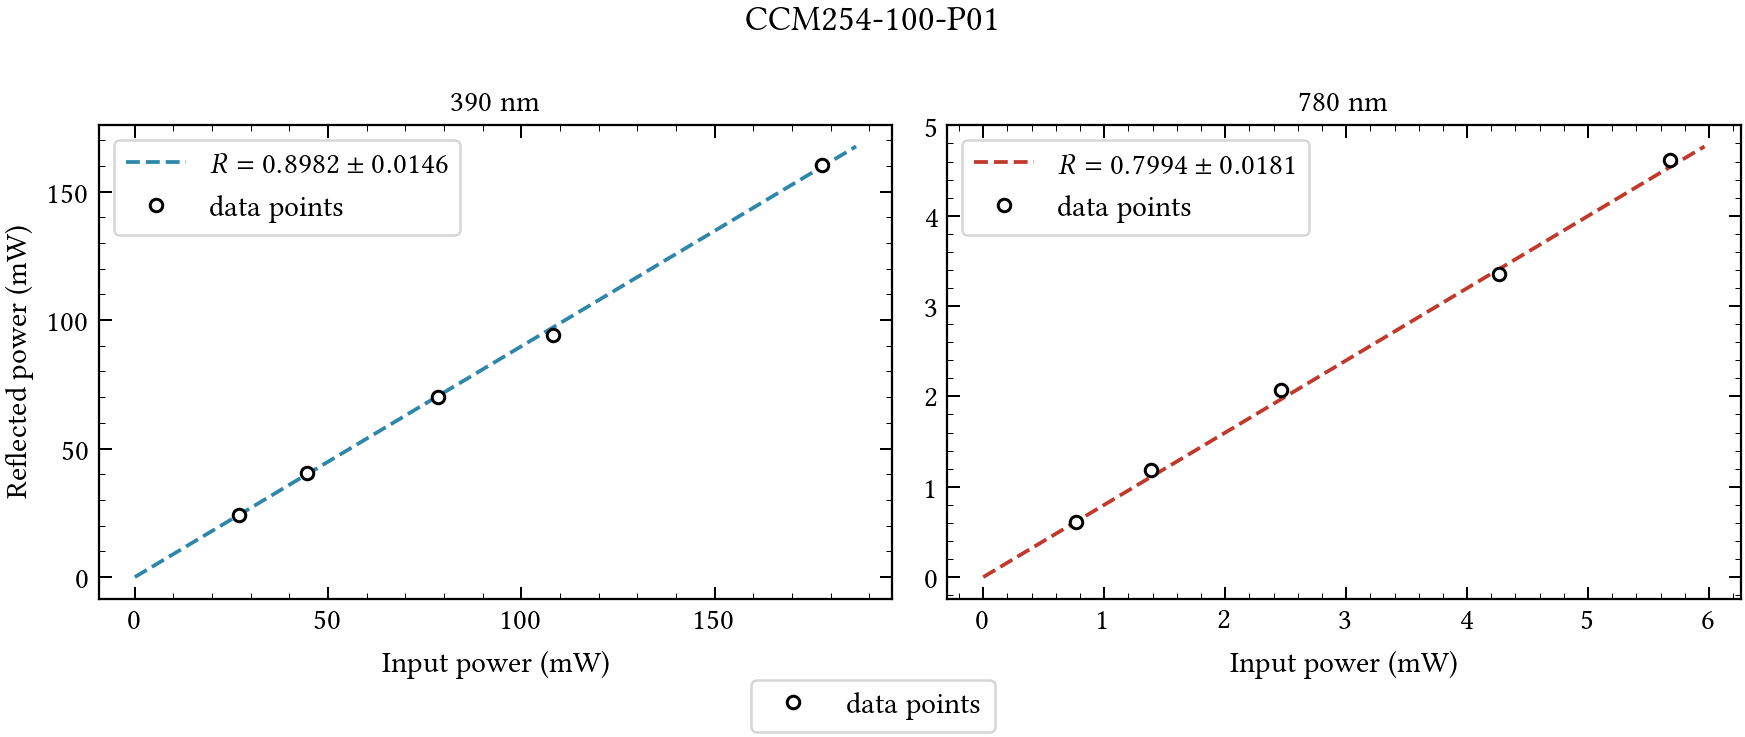

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(SAMPLE)

for ax, P_in, P_out, R, R_err, color, wl in [
    (ax1, P_in_390, P_out_390, R_390, R_390_err, "#2E86AB", "390 nm"),
    (ax2, P_in_780, P_out_780, R_780, R_780_err, "#C0392B", "780 nm"),
]:
    xfit = np.linspace(0, 1.05 * P_in.max(), 300)
    ax.plot(xfit, linear(xfit, R, 0), "--", color=color, linewidth=1.5,
            label=rf"$R = {R:.4f} \pm {R_err:.4f}$")
    ax.plot(P_in, P_out, "o", color="black", markersize=5,
            markerfacecolor="white", markeredgewidth=1.2, label="data points")
    ax.set_xlabel("Input power (mW)")
    ax.set_title(wl)
    ax.legend()

ax1.set_ylabel("Reflected power (mW)")

# move the "data points" entry to a shared figure legend at the bottom
data_handle = ax1.get_lines()[1]  # the "o" plot is the second line
fig.legend(handles=[data_handle], loc="lower center", bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

# SHG vs Input power

In [44]:
# path_folder_data = r'data/data_powermeter/power_scan_shg/2026-06-11_ppktp_svenska_10_001/power_scan_shg_ppktp_svenska_10'
# path_folder_data = r'data/data_powermeter/power_scan_shg/2026-06-12_ppktp_svenska_10_001/power_scan_shg_ppktp_svenska_10'
# path_folder_data = r'data/data_powermeter/power_scan_shg/2026-06-12_ppktp_svenska_10_002/power_scan_shg_ppktp_svenska_10'
# path_folder_data = r'data/data_powermeter/power_scan_shg/2026-06-12_ppktp_svenska_20_jesse_001/power_scan_shg_ppktp_svenska_20_jesse' # bad temperature
path_folder_data = r'data/data_powermeter/power_scan_shg/2026-06-12_ppktp_svenska_20_jesse_002/power_scan_shg_ppktp_svenska_20_jesse'

In [57]:
aqm = AcquisitionAnalysisManager(path_folder_data)
files = sorted(os.listdir(path_folder_data))

print(files)

['2026_06_12__15_59_08__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__15_59_30__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__15_59_54__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_02_06__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_02_57__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_05_06__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_06_34__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_08_08__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_08_32__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_10_33__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_10_55__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_12_29__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_12_53__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_14_16__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_14_48__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_

In [59]:
files_input = files[0::2]
files_output = files[1::2]

print("Input files: ", files_input, len(files_input))
print("Output files: ", files_output, len(files_output))

Input files:  ['2026_06_12__15_59_08__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__15_59_54__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_02_57__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_06_34__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_08_32__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_10_55__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_12_53__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_14_48__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_16_02__power_scan_shg_ppktp_svenska_20_jesse.h5'] 9
Output files:  ['2026_06_12__15_59_30__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_02_06__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_05_06__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_08_08__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_10_33__power_scan_shg_ppktp_svenska_20_jesse.h5', '2026_06_12__16_12_29__power_scan_shg_ppktp

In [62]:
P_in = []
P_out = []
T_meas = []

for f_in, f_out in zip(files_input, files_output):
    # check keys in the data dictionary
    aqm.analysis_cell(filename=os.path.join(path_folder_data, f_in))
    in_mean_mW = float(aqm.data["mean_mW"])

    aqm.analysis_cell(filename=os.path.join(path_folder_data, f_out))
    try:
        out_mean_mW = float(aqm.data["mean_mW"])
        t_meas = float(aqm.data["Tmeas"])

        P_in.append(in_mean_mW)
        P_out.append(out_mean_mW)
        T_meas.append(t_meas)

    except (KeyError, ValueError):
        print(f"Error processing file: {f_out}")
        continue

P_in = np.array(P_in)
P_out = np.array(P_out)
T_meas = np.array(T_meas)

print("Input power (mW): ", P_in)
print("Output power (mW): ", P_out)

INFO:2026_06_12__15_59_08__power_scan_shg_ppktp_svenska_20_jesse


INFO:2026_06_12__15_59_30__power_scan_shg_ppktp_svenska_20_jesse


INFO:2026_06_12__15_59_54__power_scan_shg_ppktp_svenska_20_jesse


INFO:2026_06_12__16_02_06__power_scan_shg_ppktp_svenska_20_jesse


Error processing file: 2026_06_12__16_02_06__power_scan_shg_ppktp_svenska_20_jesse.h5


...

INFO:2026_06_12__16_14_48__power_scan_shg_ppktp_svenska_20_jesse


INFO:2026_06_12__16_15_35__power_scan_shg_ppktp_svenska_20_jesse


INFO:2026_06_12__16_16_02__power_scan_shg_ppktp_svenska_20_jesse


INFO:2026_06_12__16_17_25__power_scan_shg_ppktp_svenska_20_jesse


Input power (mW):  [105.43899635  79.66685892  69.70518121  59.61899198  50.81775467
  38.7093082   28.89932701  22.89957778]
Output power (mW):  [15.0738852  10.15047822  8.09656507  6.15089808  5.14345514  3.57547515
  2.27235504  1.63956491]


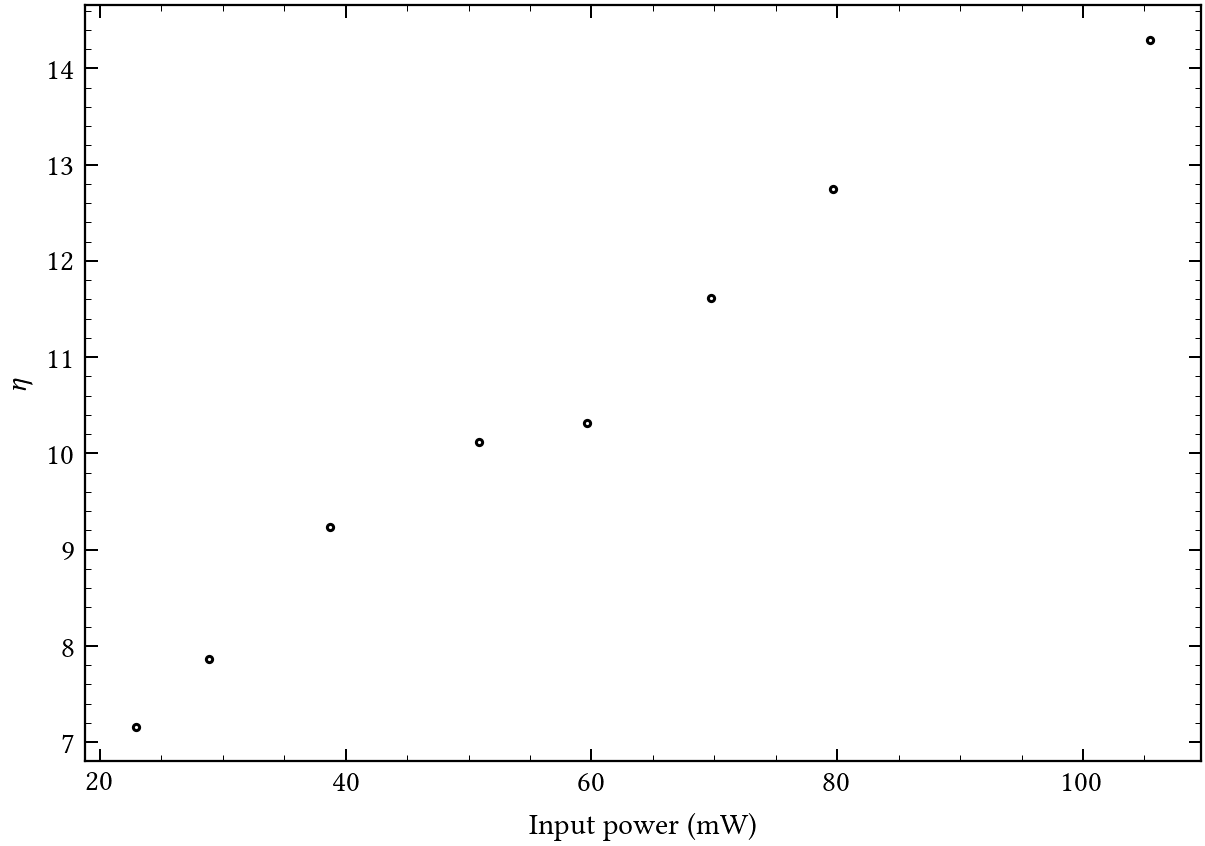

In [63]:
# Figure
fig, ax1 = plt.subplots(figsize=(7, 5))

eta = P_out / P_in * 100  # conversion to percentage

# -------------------------


# plt.plot(P_in, P_out, ".", color="black", markersize=5,
#          markerfacecolor="white", markeredgewidth=1.2, label="data points")
plt.plot(P_in, eta , ".", color="black", markersize=5,
         markerfacecolor="white", markeredgewidth=1.2, label="data points")
plt.xlabel("Input power (mW)")
# plt.ylabel("Output power (mW)")
plt.ylabel(r"$\eta$")
# plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# SHG saturation model
def eta_model(P, eta_max, kappa):
    """
    P        : input power (mW)
    eta_max  : maximum conversion efficiency (fraction, not %)
    kappa    : nonlinear coupling parameter
    """
    return eta_max * np.tanh(np.sqrt(kappa * P))**2

In [65]:
# efficiency as a fraction
eta_frac = P_out / P_in

# remove any zero-power points
mask = np.isfinite(eta_frac) & (P_in > 0)

popt, pcov = curve_fit(
    eta_model,
    P_in[mask],
    eta_frac[mask],
    p0=[0.6, 0.01]
)

eta_max, kappa = popt

print(f"eta_max = {eta_max:.4f}")
print(f"kappa   = {kappa:.6f}")

# smooth curve for plotting
P_fit = np.linspace(0, P_in.max(), 500)

eta_fit = eta_model(P_fit, *popt)      # fraction
Pout_fit = P_fit * eta_fit             # mW

eta_max = 0.1593
kappa   = 0.025050


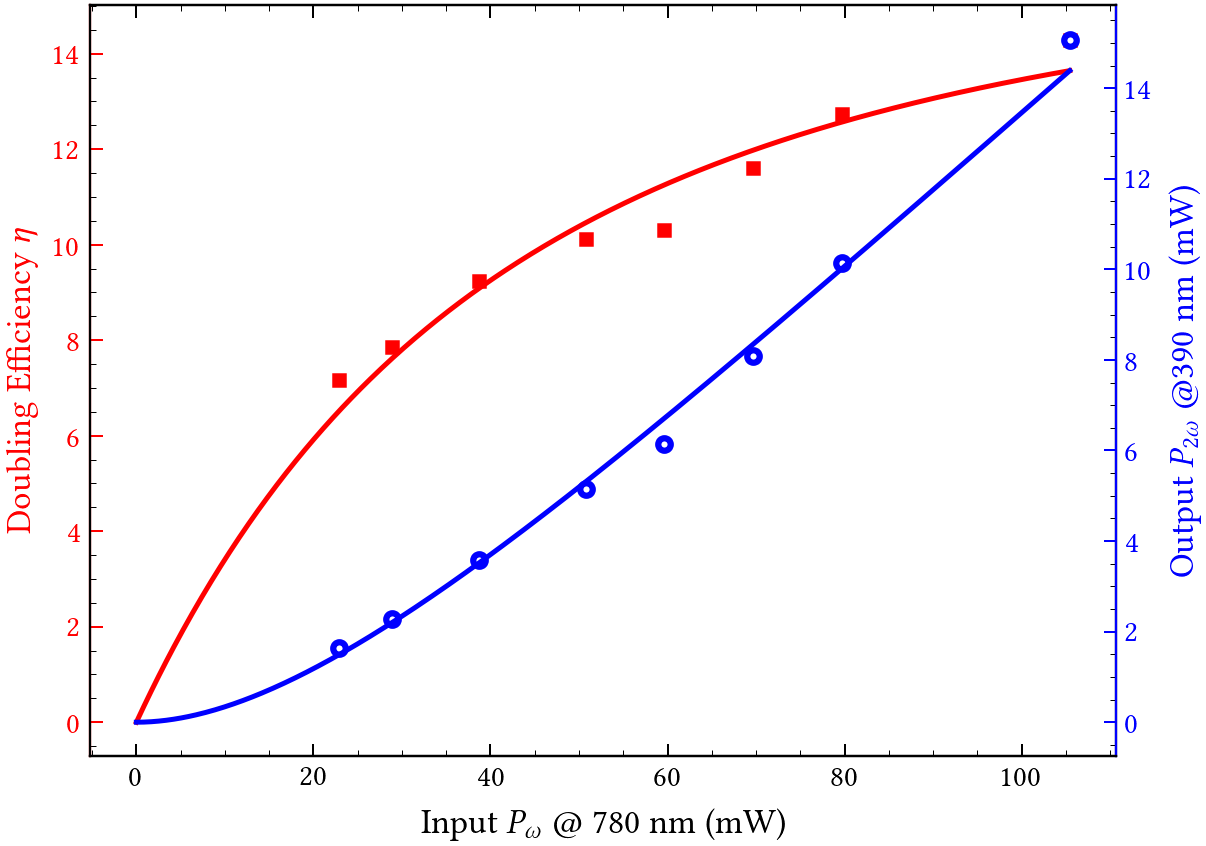

In [66]:
# Doubling efficiency (%)
eta = 100 * P_out / np.where(P_in == 0, np.nan, P_in)

fig, ax1 = plt.subplots(figsize=(7, 5))

# -------------------------
# Left axis: efficiency
# -------------------------
ax1.plot(
    P_in, eta,
    's', color='red',
    markersize=5,
    markerfacecolor='red',
    label='Efficiency'
)

ax1.plot(
    P_fit,
    100 * eta_fit,
    '-',
    color='red',
    lw=2
)

ax1.set_xlabel(r'Input $P_\omega$ @ 780 nm (mW)', fontsize=14)
ax1.set_ylabel(r'Doubling Efficiency $\eta$',
               color='red', fontsize=14)

ax1.tick_params(axis='y', colors='red')

# -------------------------
# Right axis: UV output power
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    P_in, P_out,
    'o',
    color='blue',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=2.5,
    label='UV power'
)

ax2.plot(
    P_fit,
    Pout_fit,
    '-',
    color='blue',
    lw=2
)

ax2.set_ylabel(r'Output $P_{2\omega}$ @390 nm (mW)',
               color='blue', fontsize=14)

ax2.tick_params(axis='y', colors='blue')


# Styling
ax1.spines['left'].set_color('red')
ax2.spines['right'].set_color('blue')

ax1.tick_params(labelsize=12)
ax2.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

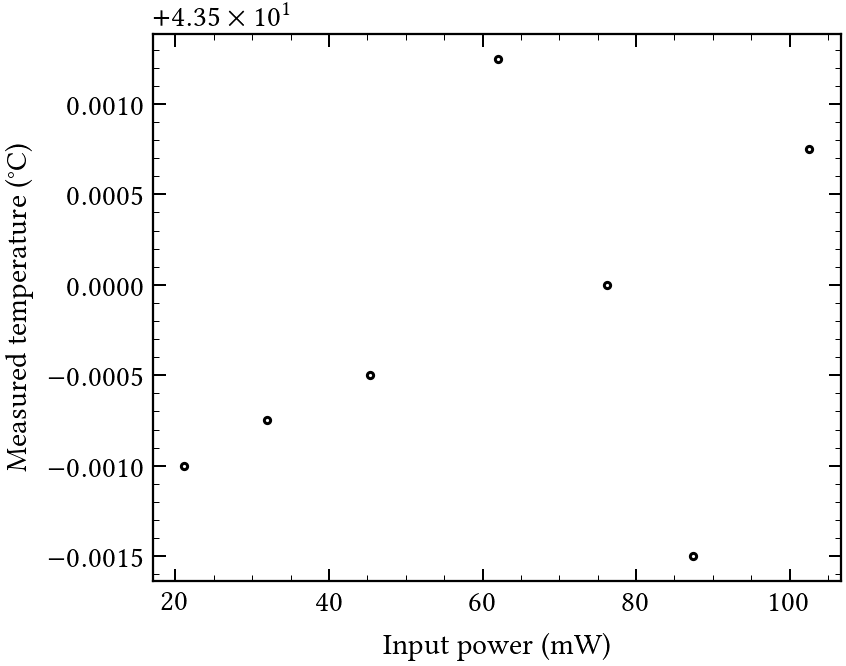

In [41]:
# Figure temp vs power
plt.figure(figsize=(5, 4))
plt.plot(P_in, T_meas, ".", color="black", markersize=5,
            markerfacecolor="white", markeredgewidth=1.2, label="data points")
plt.xlabel("Input power (mW)")
plt.ylabel("Measured temperature (°C)")
# plt.legend()
plt.tight_layout()
plt.show()